In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer # dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#


In [25]:
# step 1 data load
data = load_breast_cancer()
X = data.data # Features
y = data.target # labels (0 = molignant , 1 benign)

In [26]:
#split 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# make numbers similer size for better traning....
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# build the model
model = Sequential([
    Dense(16, activation='relu' , input_shape=(X_train.shape[1],)), # hidden layer 1
    Dense(8, activation='relu'), # hidden layer 2
    Dense(1, activation='sigmoid') # output with sigmoid
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# complie (Setup traning)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
# train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5714 - loss: 0.7588 - val_accuracy: 0.6813 - val_loss: 0.6714
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6648 - loss: 0.6019 - val_accuracy: 0.8022 - val_loss: 0.5216
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7995 - loss: 0.4824 - val_accuracy: 0.8571 - val_loss: 0.4180
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8791 - loss: 0.3951 - val_accuracy: 0.8791 - val_loss: 0.3494
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9066 - loss: 0.3321 - val_accuracy: 0.8901 - val_loss: 0.3012
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9258 - loss: 0.2843 - val_accuracy: 0.9121 - val_loss: 0.2658
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9341 - loss: 0.2469 - val_accuracy: 0.9231 - val_loss: 0.2383
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2173 - val_accuracy: 0.9451 - val_loss

In [31]:
# test and print accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9825 - loss: 0.0763 
Test accuracy: 0.9824561476707458


(0.5, 1.0)

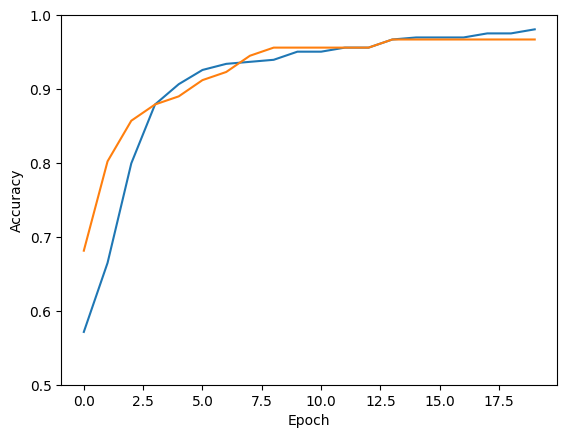

In [32]:
# plot traning progress
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])